# Step 5 — VAE + Classifier

**Architecture source**: `ipynbs/Lecture_8_Generating_Synthetic_Faces_using_VAEs_and_Wasserstein_GANs.ipynb`

## Why VAE after Transformer?

The PatchTransformer (0.384) underperformed GeneAtt v2 (0.404) — small dataset (6824 source samples) is not enough to train 120-token attention effectively. The VAE takes a completely different approach:

1. **Phase 1 — Unsupervised pretraining**: Train the VAE encoder+decoder on **both source AND target** (63877+6824 cells). The decoder forces the latent space to be smooth and continuous. Domain-specific noise is averaged out since the VAE must reconstruct both.
2. **Phase 2 — Supervised fine-tuning**: Freeze the encoder, train a classifier head on top of `z` (latent) using only source labels.
3. **Evaluate**: Apply the frozen encoder to CORAL-aligned target → classify with the trained head.

```
Phase 1 (both domains, unsupervised):
  X → Encoder → μ, σ → z = μ + ε·σ → Decoder → X̂
  Loss = Reconstruction (MSE) + β·KL(N(μ,σ) ∥ N(0,1))

Phase 2 (source only, supervised):
  X_src → Encoder (frozen) → μ → Classifier → 6-class softmax
  Loss = CE (class-weighted)
```

**Progression:**
| Model | Source F1 | Target F1 |
|---|---|---|
| DANN v2 | 0.875 | 0.395 |
| GeneAtt v2 (CORAL+MMD) | 0.893 | **0.404** ← best |
| PatchTransformer | 0.772 | 0.384 |

In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step5_vae' else Path.cwd()
RESULTS_DIR  = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0


## 1. Data Loading + CORAL Alignment

In [2]:
X_train = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes   = len(class_names)
n_genes     = X_train.shape[1]

X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)
df_labels    = pd.read_csv(PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv')
mask         = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

classes, counts = np.unique(y_train, return_counts=True)
class_weight = {int(c): len(y_train) / (n_classes * cnt) for c, cnt in zip(classes, counts)}

print(f'Source train: {X_train.shape}  Target: {X_target_raw.shape}')
print(f'n_genes={n_genes}  classes={class_names}')

Source train: (6824, 3000)  Target: (63877, 3000)
n_genes=3000  classes=['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']


In [3]:
def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - X_tgt.mean(axis=0)
    Cs = (Xs.T @ Xs) / (Xs.shape[0] - 1) + reg * np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0] - 1) + reg * np.eye(Xt.shape[1])

    def mat_sqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(np.sqrt(np.maximum(v, 0))) @ V.T

    def mat_inv_sqrt(M):
        v, V = np.linalg.eigh(M)
        return V @ np.diag(1.0 / np.sqrt(np.maximum(v, 1e-10))) @ V.T

    W = mat_inv_sqrt(Ct) @ mat_sqrt(Cs)
    return ((Xt @ W) + src_mean).astype(np.float32)

print('Running CORAL alignment...')
X_target_coral = coral_align(X_train, X_target_raw)
X_target_eval  = X_target_coral[mask.values]

# Combined dataset for VAE pretraining (both domains — the key advantage)
X_combined = np.concatenate([X_train, X_target_coral], axis=0)
np.random.shuffle(X_combined)

print(f'CORAL done. Target eval: {X_target_eval.shape}')
print(f'Combined VAE pretraining set: {X_combined.shape}')

Running CORAL alignment...
CORAL done. Target eval: (12776, 3000)
Combined VAE pretraining set: (70701, 3000)


## 2. VAE Architecture

Adapted from `Lecture_8` (VAE with reparameterisation trick). Input is 3000-dim PCA features instead of images — we use Dense layers instead of Conv.

**β-VAE**: using β=0.5 to balance reconstruction quality vs. latent smoothness. Higher β → smoother latent (better for transfer), lower β → better reconstruction.

In [4]:
LATENT_DIM = 128
BETA       = 0.5    # KL weight — β-VAE

class Sampling(layers.Layer):
    """Reparameterisation trick: z = μ + ε·σ, ε ~ N(0,1)."""
    def call(self, inputs):
        mu, log_var = inputs
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * log_var) * eps


def build_encoder(input_dim, latent_dim):
    inputs  = keras.Input(shape=(input_dim,), name='encoder_input')
    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.2)(x)
    mu      = layers.Dense(latent_dim, name='mu')(x)
    log_var = layers.Dense(latent_dim, name='log_var')(x)
    z       = Sampling(name='z')([mu, log_var])
    return keras.Model(inputs, [mu, log_var, z], name='encoder')


def build_decoder(latent_dim, output_dim):
    inputs = keras.Input(shape=(latent_dim,), name='decoder_input')
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    outputs = layers.Dense(output_dim, activation='linear', name='reconstruction')(x)
    return keras.Model(inputs, outputs, name='decoder')


encoder = build_encoder(n_genes, LATENT_DIM)
decoder = build_decoder(LATENT_DIM, n_genes)
encoder.summary()
print(f'\nLatent dim: {LATENT_DIM}  β: {BETA}')

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 3000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,536,512 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 512)       │      1,024 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256)       │        512 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 128)       │          0 │ mu[0][0],         │
│                     │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,735,168 (6.62 MB)

 Trainable params: 1,735,168 (6.62 MB)

 Non-trainable params: 0 (0.00 B)


Latent dim: 128  β: 0.5


In [5]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta
        self.recon_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_tracker    = keras.metrics.Mean(name='kl_loss')
        self.total_tracker = keras.metrics.Mean(name='loss')

    def call(self, x, training=False):
        mu, log_var, z = self.encoder(x, training=training)
        return self.decoder(z, training=training)

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            mu, log_var, z = self.encoder(x, training=True)
            x_hat = self.decoder(z, training=True)

            # Reconstruction: MSE (gene expression is continuous)
            recon = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_hat), axis=1))

            # KL divergence: -0.5 * sum(1 + log_var - mu² - exp(log_var))
            kl = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
            )
            total = recon + self.beta * kl

        grads = tape.gradient(total, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.recon_tracker.update_state(recon)
        self.kl_tracker.update_state(kl)
        self.total_tracker.update_state(total)
        return {'loss': self.total_tracker.result(),
                'recon_loss': self.recon_tracker.result(),
                'kl_loss': self.kl_tracker.result()}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        mu, log_var, z = self.encoder(x, training=False)
        x_hat = self.decoder(z, training=False)
        recon = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_hat), axis=1))
        kl    = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1.0 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
        )
        total = recon + self.beta * kl
        self.recon_tracker.update_state(recon)
        self.kl_tracker.update_state(kl)
        self.total_tracker.update_state(total)
        return {'loss': self.total_tracker.result(),
                'recon_loss': self.recon_tracker.result(),
                'kl_loss': self.kl_tracker.result()}

    @property
    def metrics(self):
        return [self.total_tracker, self.recon_tracker, self.kl_tracker]

vae = VAE(encoder, decoder, beta=BETA, name='vae')
vae.compile(optimizer=keras.optimizers.Adam(1e-4))
print('VAE compiled.')

VAE compiled.


## 3. Phase 1 — VAE Pretraining (Both Domains)

In [6]:
VAE_EPOCHS    = 60
VAE_BATCH     = 256
VAE_PATIENCE  = 10

vae_ds = (
    tf.data.Dataset.from_tensor_slices(X_combined)
    .shuffle(80000, seed=42)
    .batch(VAE_BATCH)
)
vae_val_ds = tf.data.Dataset.from_tensor_slices(X_test).batch(VAE_BATCH)

vae_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', mode='min',
        patience=VAE_PATIENCE, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', mode='min',
        factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
]

print(f'Pretraining VAE on {X_combined.shape[0]} cells (source + target)...')
vae_history = vae.fit(
    vae_ds,
    epochs=VAE_EPOCHS,
    validation_data=vae_val_ds,
    callbacks=vae_callbacks,
    verbose=1
)

Pretraining VAE on 70701 cells (source + target)...
Epoch 1/60
277/277 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - kl_loss: 182.5423 - loss: 2915.8528 - recon_loss: 2824.5825 - val_kl_loss: 124.5118 - val_loss: 2950.5212 - val_recon_loss: 2888.2654 - learning_rate: 1.0000e-04
Epoch 2/60
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - kl_loss: 109.6987 - loss: 2557.6736 - recon_loss: 2502.8252 - val_kl_loss: 69.0006 - val_loss: 2883.8362 - val_recon_loss: 2849.3359 - learning_rate: 1.0000e-04
Epoch 3/60
277/277 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - kl_loss: 79.4799 - loss: 2503.0771 - recon_loss: 2463.3374 - val_kl_loss: 55.5671 - val_loss: 2878.3853 - val_recon_loss: 2850.6016 - learning_rate: 1.0000e-04
Epoch 4/60
277/277 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - kl_loss: 68.0731 - loss: 2476.5986 - recon_loss: 2442.5618 - val_kl_loss: 51.6112 - val_loss: 2856.5286 - val_recon_loss: 2830.7229 - learning_rate: 1.0000e-04
Epoch 5/60
277/277 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - kl_loss: 62.9263 - loss: 2459.

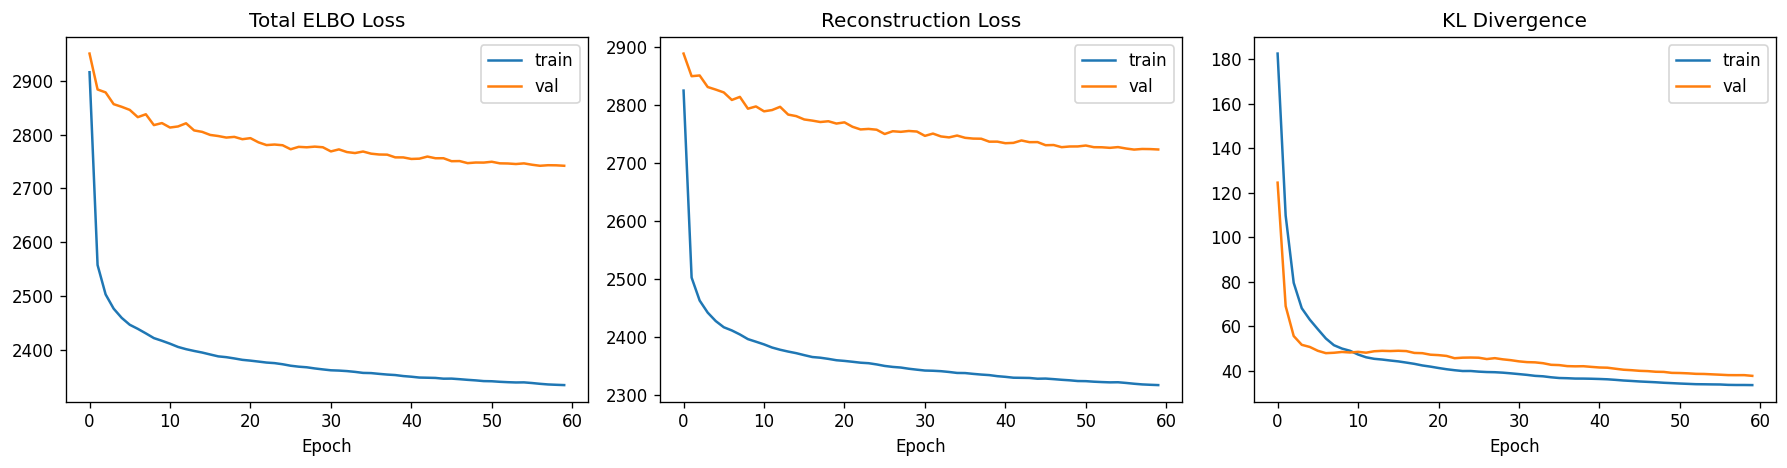

VAE trained for 60 epochs.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in [
    (axes[0], 'loss',       'Total ELBO Loss'),
    (axes[1], 'recon_loss', 'Reconstruction Loss'),
    (axes[2], 'kl_loss',    'KL Divergence'),
]:
    ax.plot(vae_history.history[key],       label='train')
    ax.plot(vae_history.history[f'val_{key}'], label='val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'vae_pretraining_curves.png', bbox_inches='tight')
plt.show()
print(f'VAE trained for {len(vae_history.history["loss"])} epochs.')

## 4. Phase 2 — Classifier on Frozen Encoder

In [8]:
# Freeze the encoder — use only μ (mean) as deterministic representation
encoder.trainable = False

def build_classifier_head(latent_dim, n_classes):
    inp = keras.Input(shape=(latent_dim,))
    x   = layers.Dense(128, activation='relu')(inp)
    x   = layers.LayerNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='classifier_head')

clf_head = build_classifier_head(LATENT_DIM, n_classes)

# Full pipeline: input → encoder (frozen) → μ → classifier
inputs   = keras.Input(shape=(n_genes,))
mu, _, _ = encoder(inputs, training=False)
logits   = clf_head(mu)
clf_model = keras.Model(inputs, logits, name='vae_classifier')

clf_model.compile(
    optimizer=keras.optimizers.Adam(2e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
clf_model.summary()
print(f'\nEncoder frozen (trainable params: {clf_head.count_params():,})')

Model: "vae_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 3000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ [(None, 128), (None,   │     1,735,168 │
│                                 │ 128), (None, 128)]     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_head (Functional)    │ (None, 6)              │        25,414 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,760,582 (6.72 MB)

 Trainable params: 25,414 (99.27 KB)

 Non-trainable params: 1,735,168 (6.62 MB)


Encoder frozen (trainable params: 25,414)


In [9]:
CLF_EPOCHS   = 100
CLF_BATCH    = 128
CLF_PATIENCE = 15

clf_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', mode='min',
        patience=CLF_PATIENCE, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', mode='min',
        factor=0.5, patience=7, min_lr=1e-6, verbose=1
    ),
]

clf_history = clf_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=CLF_EPOCHS,
    batch_size=CLF_BATCH,
    class_weight=class_weight,
    callbacks=clf_callbacks,
    verbose=1
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2696 - loss: 2.0256 - val_accuracy: 0.6231 - val_loss: 1.1589 - learning_rate: 2.0000e-04
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5192 - loss: 1.2781 - val_accuracy: 0.7726 - val_loss: 0.7894 - learning_rate: 2.0000e-04
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6360 - loss: 0.9984 - val_accuracy: 0.8124 - val_loss: 0.6220 - learning_rate: 2.0000e-04
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6905 - loss: 0.8380 - val_accuracy: 0.8406 - val_loss: 0.5242 - learning_rate: 2.0000e-04
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7378 - loss: 0.7173 - val_accuracy: 0.8511 - val_loss: 0.4757 - learning_rate: 2.0000e-04
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7597 - loss: 0.6777 - val_accuracy: 0.8535 - val_loss: 0.4471 - learning_rate: 2.0000e-04
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7759 

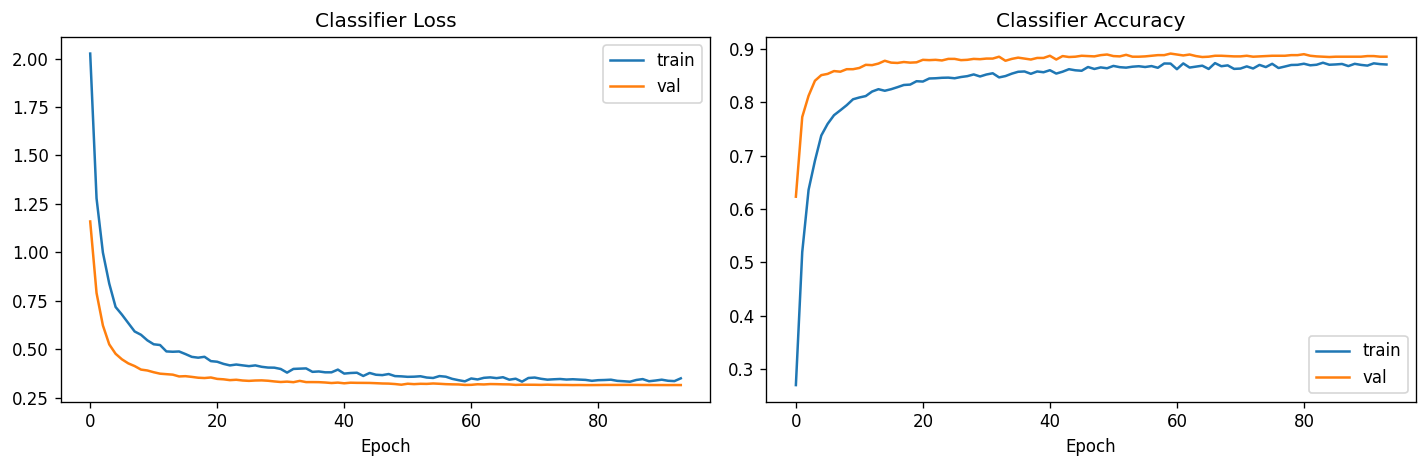

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(clf_history.history['loss'],     label='train')
axes[0].plot(clf_history.history['val_loss'], label='val')
axes[0].set_title('Classifier Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(clf_history.history['accuracy'],     label='train')
axes[1].plot(clf_history.history['val_accuracy'], label='val')
axes[1].set_title('Classifier Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'clf_training_curves.png', bbox_inches='tight')
plt.show()

## 5. Evaluate — Source Test

In [11]:
y_pred_src = np.argmax(clf_model.predict(X_test, batch_size=CLF_BATCH), axis=1)
src_f1 = f1_score(y_test, y_pred_src, average='macro')
print(f'Source Test Macro F1: {src_f1:.4f}')
print(classification_report(y_test, y_pred_src, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Source Test Macro F1: 0.8806
              precision    recall  f1-score   support

    Effector       0.93      0.90      0.92       482
   Exhausted       0.87      0.96      0.92       166
       Naive       0.81      0.88      0.84       224
   Other_CD4       0.85      0.80      0.82       321
    Th1-like       0.80      0.89      0.84       141
        Treg       0.97      0.92      0.94       372

    accuracy                           0.89      1706
   macro avg       0.87      0.89      0.88      1706
weighted avg       0.89      0.89      0.89      1706



## 6. Evaluate — Target Domain (CORAL-aligned)

In [12]:
y_pred_tgt = np.argmax(clf_model.predict(X_target_eval, batch_size=CLF_BATCH), axis=1)
tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Target Macro F1: {tgt_f1:.4f}')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Target Macro F1: 0.3829
              precision    recall  f1-score   support

    Effector       0.55      0.50      0.52      2839
   Exhausted       0.06      0.09      0.07       903
       Naive       0.83      0.52      0.64      3806
   Other_CD4       0.37      0.32      0.34      2127
    Th1-like       0.16      0.24      0.19      1031
        Treg       0.44      0.67      0.53      2070

    accuracy                           0.45     12776
   macro avg       0.40      0.39      0.38     12776
weighted avg       0.52      0.45      0.47     12776



## 7. Confusion Matrices

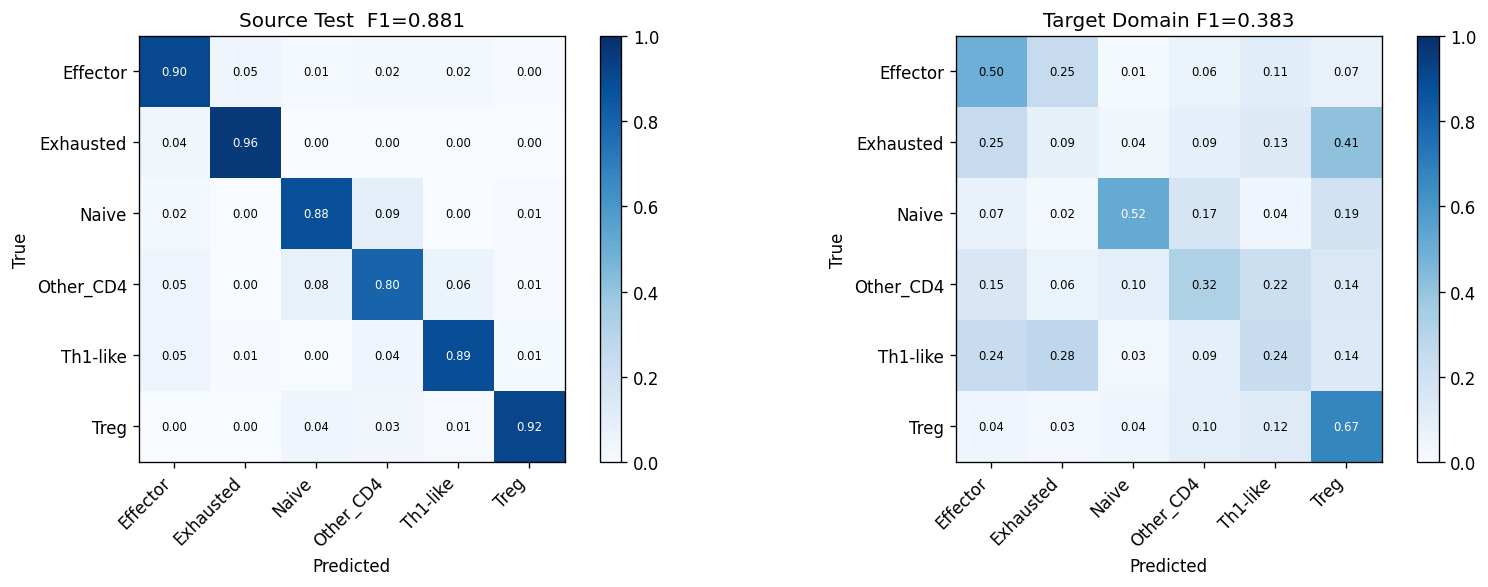

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test,        y_pred_src, f'Source Test  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target Domain F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j] > 0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

## 8. Latent Space Visualisation (UMAP / t-SNE)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Running t-SNE on latent space (may take ~1min)...


/var/folders/28/r1zy7hp93zb8w_dtfdjsms6r0000gn/T/ipykernel_73746/2338725882.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_classes)


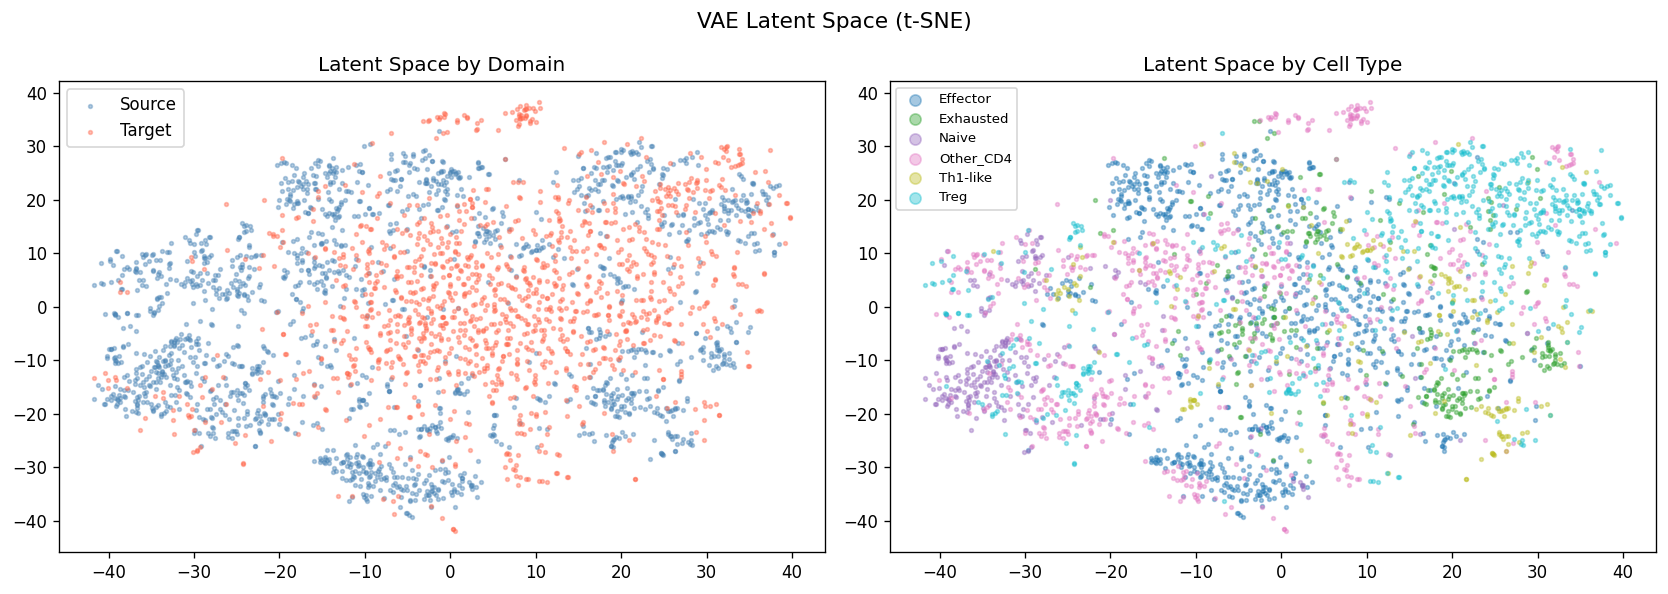

In [15]:
from sklearn.manifold import TSNE

# Get μ for source test + target eval
mu_src, _, _ = encoder.predict(X_test,        batch_size=CLF_BATCH)
mu_tgt, _, _ = encoder.predict(X_target_eval, batch_size=CLF_BATCH)

mu_all     = np.concatenate([mu_src, mu_tgt], axis=0)
domain_all = np.array([0]*len(mu_src) + [1]*len(mu_tgt))
labels_all = np.concatenate([y_test, y_target_eval], axis=0)

print('Running t-SNE on latent space (may take ~1min)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=1000)
z2d  = tsne.fit_transform(mu_all[:3000])   # subsample for speed

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_domain = ['steelblue', 'tomato']
for d, label in [(0, 'Source'), (1, 'Target')]:
    idx = domain_all[:3000] == d
    axes[0].scatter(z2d[idx, 0], z2d[idx, 1], c=colors_domain[d], alpha=0.4, s=5, label=label)
axes[0].set_title('Latent Space by Domain'); axes[0].legend()

cmap = plt.cm.get_cmap('tab10', n_classes)
for cls_idx, cls_name in enumerate(class_names):
    idx = labels_all[:3000] == cls_idx
    axes[1].scatter(z2d[idx, 0], z2d[idx, 1], c=[cmap(cls_idx)], alpha=0.4, s=5, label=cls_name)
axes[1].set_title('Latent Space by Cell Type'); axes[1].legend(markerscale=3, fontsize=8)

plt.suptitle('VAE Latent Space (t-SNE)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'latent_space_tsne.png', bbox_inches='tight')
plt.show()

## 9. Full Comparison Table + Save

In [16]:
src_report = classification_report(y_test,        y_pred_src, target_names=class_names, output_dict=True)
tgt_report = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)

results = {
    'model': 'VAE_Classifier',
    'config': {
        'latent_dim': LATENT_DIM, 'beta': BETA,
        'vae_epochs': len(vae_history.history['loss']),
        'clf_epochs': len(clf_history.history['loss']),
        'encoder_frozen': True, 'coral_aligned': True, 'class_weighted': True,
        'pretraining_data': 'source + target (both domains)',
    },
    'source_test': {
        'macro_f1': src_f1,
        'accuracy': accuracy_score(y_test, y_pred_src),
        'per_class_f1': {cls: src_report[cls]['f1-score'] for cls in class_names},
    },
    'target_eval': {
        'macro_f1': tgt_f1,
        'accuracy': accuracy_score(y_target_eval, y_pred_tgt),
        'per_class_f1': {cls: tgt_report[cls]['f1-score'] for cls in class_names},
        'n_eval_cells': int(y_target_eval.shape[0]),
    },
}
with open(RESULTS_DIR / 'vae_results.json', 'w') as f:
    json.dump(results, f, indent=2)

encoder.save(str(RESULTS_DIR / 'vae_encoder.keras'))
clf_head.save(str(RESULTS_DIR / 'classifier_head.keras'))

all_models = [
    ('LogReg',                     0.885, None),
    ('MLP',                        0.884, None),
    ('MMD-Net',                    None,  0.194),
    ('DANN v1',                    0.852, 0.391),
    ('DANN v2',                    0.875, 0.395),
    ('GeneAtt v1 (no align)',      0.894, 0.079),
    ('GeneAtt v2 (CORAL+MMD)',     0.893, 0.404),
    ('PatchTransformer (CORAL+MMD)', 0.772, 0.384),
    ('VAE + Classifier',           src_f1, tgt_f1),
]

best_tgt = max(tf_ for _, _, tf_ in all_models if tf_ is not None)
print(f'\n{"Model":32s} {"Source F1":>10s} {"Target F1":>10s}')
print('-' * 58)
for name, sf, tf_ in all_models:
    s = f'{sf:.3f}' if sf is not None else '   —  '
    t = f'{tf_:.3f}' if tf_ is not None else '   —  '
    marker = ' ◄ best' if tf_ is not None and tf_ == best_tgt else ''
    print(f'{name:32s} {s:>10s} {t:>10s}{marker}')


Model                             Source F1  Target F1
----------------------------------------------------------
LogReg                                0.885        —  
MLP                                   0.884        —  
MMD-Net                                 —        0.194
DANN v1                               0.852      0.391
DANN v2                               0.875      0.395
GeneAtt v1 (no align)                 0.894      0.079
GeneAtt v2 (CORAL+MMD)                0.893      0.404 ◄ best
PatchTransformer (CORAL+MMD)          0.772      0.384
VAE + Classifier                      0.881      0.383
